# Filters and Edge Detection

## Goal
Understand how filters extract features from images.
Filters are the foundation of CNNs — every convolutional layer is a learned filter.

## Key Questions
- What is a convolution filter?
- How do different filters detect different features?
- What is edge detection and why does it matter?

## What We Build
Manual implementation of Gaussian blur, Sobel edge detection, and Laplacian filter.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request

## 1. Load a Real Image
We need a real photo to see filters in action.

Image shape: (200, 200, 3)
Grayscale shape: (200, 200)


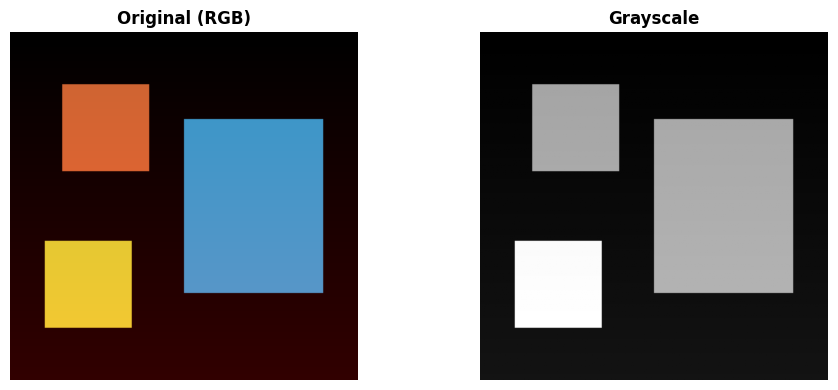

In [9]:
# Create a synthetic test image with clear features
np.random.seed(42)
img = np.zeros((200, 200, 3), dtype=np.uint8)

# Add shapes
img[30:80, 30:80] = [200, 100, 50]      # square
img[50:150, 100:180] = [50, 150, 200]   # rectangle
img[120:170, 20:70] = [200, 200, 50]    # yellow square

# Add gradient background
for i in range(200):
    img[i, :, 0] = np.clip(img[i, :, 0] + i//4, 0, 255)

# Grayscale
gray = (0.299 * img[:,:,0] + 0.587 * img[:,:,1] + 0.114 * img[:,:,2]).astype(np.float32)

print(f"Image shape: {img.shape}")
print(f"Grayscale shape: {gray.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img)
axes[0].set_title("Original (RGB)", fontweight="bold")
axes[0].axis("off")
axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Grayscale", fontweight="bold")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("original_image.png", dpi=300)
plt.show()

## 2. Convolution Function

In [11]:
def convolve2d(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """
    Apply a 2D convolution filter to an image.
    Uses zero-padding to maintain image size.
    """
    h, w = image.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

    # Zero padding
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant")

    output = np.zeros_like(image, dtype=np.float32)
    for i in range(h):
        for j in range(w):
            output[i, j] = np.sum(padded[i:i+kh, j:j+kw] * kernel)

    return output

print("convolve2d defined.")
print("Uses zero-padding - output same size as input.")

convolve2d defined.
Uses zero-padding - output same size as input.


## 3. Gaussian Blur
Reduces noise by averaging neighboring pixels with a Gaussian weight.

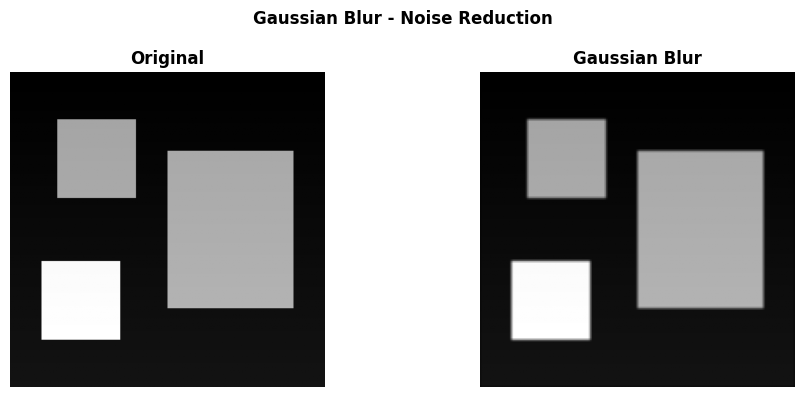

Kernel sum: 1.0 (should be 1.0 — preserves brightness)


In [13]:
# Gaussian blur kernel - smooths the image
gaussian_kernel = np.array([
    [1,  2,  1],
    [2,  4,  2],
    [1,  2,  1],
], dtype=np.float32) / 16.0

blurred = convolve2d(gray, gaussian_kernel)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original", fontweight="bold")
axes[0].axis("off")
axes[1].imshow(blurred, cmap="gray")
axes[1].set_title("Gaussian Blur", fontweight="bold")
axes[1].axis("off")
plt.suptitle("Gaussian Blur - Noise Reduction", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("gaussian_blur.png", dpi=300)
plt.show()

print(f"Kernel sum: {gaussian_kernel.sum():.1f} (should be 1.0 — preserves brightness)")

## 4. Sobel Edge Detection
Detects edges by finding areas of high gradient (rapid pixel change).

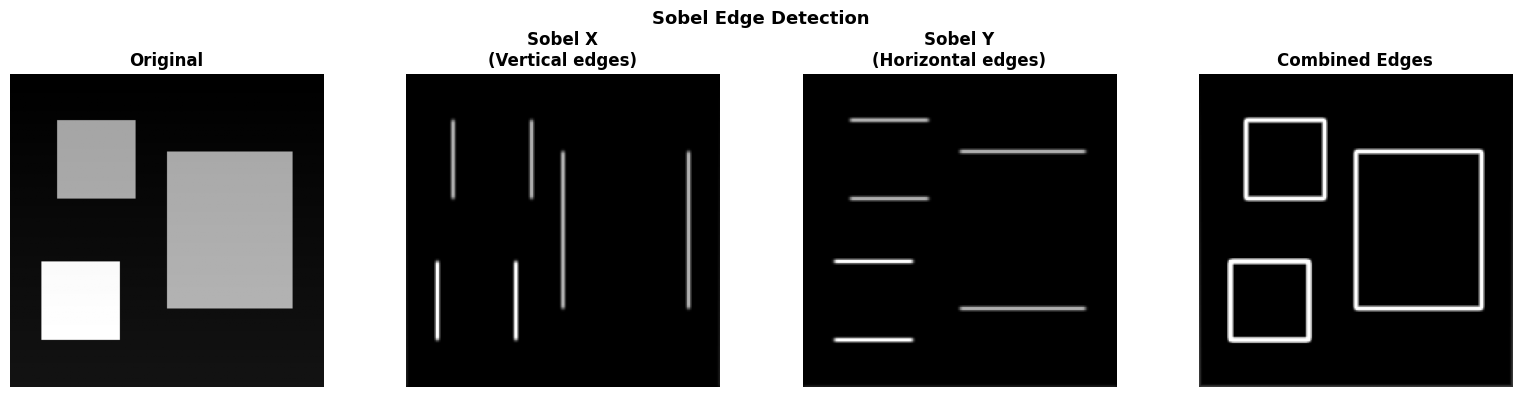

In [14]:
# Sobel Kernels - detect horizontal and vertical edges
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
], dtype=np.float32)

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1],
], dtype=np.float32)

# Apply on blurred image (less noise)
grad_x = convolve2d(blurred, sobel_x)
grad_y = convolve2d(blurred, sobel_y)

# Combine gradients
edges = np.sqrt(grad_x**2 + grad_y**2)
edges = np.clip(edges, 0, 255)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original", fontweight="bold")
axes[0].axis("off")

axes[1].imshow(np.abs(grad_x), cmap="gray")
axes[1].set_title("Sobel X\n(Vertical edges)", fontweight="bold")
axes[1].axis("off")

axes[2].imshow(np.abs(grad_y), cmap="gray")
axes[2].set_title("Sobel Y\n(Horizontal edges)", fontweight="bold")
axes[2].axis("off")

axes[3].imshow(edges, cmap="gray")
axes[3].set_title("Combined Edges", fontweight="bold")
axes[3].axis("off")

plt.suptitle("Sobel Edge Detection", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("edge_detection.png", dpi=300)
plt.show()

## 5. Key Observations

## Filters Summary

| Filter | Kernel Sum | Effect |
|--------|-----------|--------|
| Gaussian Blur | 1.0 | Smooths — removes noise |
| Sobel X | 0 | Detects vertical edges |
| Sobel Y | 0 | Detects horizontal edges |

## Key Insight
Filters with sum = 1 preserve brightness (blur).
Filters with sum = 0 detect changes (edges).

This is exactly what CNNs learn automatically —
instead of hand-crafting filters, the network learns the best filters for the task.

## Connection to CNNs
The convolutional layers in a CNN are learned filters.
Early layers learn edge detectors (like Sobel).
Middle layers combine edges into shapes.
Deep layers combine shapes into objects.

## Next
How does a CNN learn these filters automatically?
-> 03_cnn_from_scratch.ipynb